# Target Formulation Comparison

This notebook compares four candidate-pool and target formulations for the RetailRocket purchase conversion experiment. The goal is to choose a more learnable and business-interpretable V1 target before implementing the reusable dataset builder.

No model training is performed here. The analysis uses the prepared events file as read-only input.

## 1. Notebook Purpose

This notebook answers four practical design questions:

1. Can we define a more learnable conversion-prediction task than the broad observed-pair formulation?
2. Which formulation improves positive rate while still keeping enough matched positive examples?
3. Which formulation remains stable across train, validation, and test?
4. Which formulation best balances statistical learnability, business interpretability, and candidate coverage?

## 2. Load Prepared Events

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EVENTS_PATH = PROJECT_ROOT / "data" / "interim" / "events_clean.parquet"
if not EVENTS_PATH.exists():
    raise FileNotFoundError(f"Prepared events file not found: {EVENTS_PATH}")

events = pd.read_parquet(EVENTS_PATH)
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,2015-05-03 03:00:04.384,693516,addtocart,297662,NaN
1,2015-05-03 03:00:11.289,829044,view,60987,NaN
2,2015-05-03 03:00:13.048,652699,view,252860,NaN
3,2015-05-03 03:00:24.154,1125936,view,33661,NaN
4,2015-05-03 03:00:26.228,693516,view,297662,NaN


## 3. Split Configuration

In [2]:
split_config = [
    {
        "split": "train",
        "observation_start": "2015-05-03",
        "observation_end": "2015-06-01",
        "label_start": "2015-06-02",
        "label_end": "2015-06-15",
    },
    {
        "split": "validation",
        "observation_start": "2015-06-16",
        "observation_end": "2015-07-15",
        "label_start": "2015-07-16",
        "label_end": "2015-07-29",
    },
    {
        "split": "test",
        "observation_start": "2015-07-30",
        "observation_end": "2015-08-28",
        "label_start": "2015-08-29",
        "label_end": "2015-09-11",
    },
]

splits = pd.DataFrame(split_config)
display(splits)

def inclusive_date_mask(df: pd.DataFrame, start_date: str, end_date: str) -> pd.Series:
    start = pd.Timestamp(start_date)
    end_exclusive = pd.Timestamp(end_date) + pd.Timedelta(days=1)
    return df["timestamp"].ge(start) & df["timestamp"].lt(end_exclusive)

,split,observation_start,observation_end,label_start,label_end
0,train,2015-05-03,2015-06-01,2015-06-02,2015-06-15
1,validation,2015-06-16,2015-07-15,2015-07-16,2015-07-29
2,test,2015-07-30,2015-08-28,2015-08-29,2015-09-11


## 4. Candidate Formulations

The four formulations differ only in how they define the candidate `(visitorid, itemid)` pool inside the observation window. The label is the same for all four: a positive pair has at least one `transaction` event in the following 14-day label window.

- **A - Broad Observed-Pair Baseline:** all observed visitor-item pairs.
- **B - Add-to-Cart Candidate Pairs:** pairs with at least one observation-window `addtocart`.
- **C - High-Intent Hybrid Candidate Pairs:** pairs with at least one `addtocart` or at least two `view` events.
- **D - Recent Interaction Candidate Pairs:** pairs observed at least once during the final 7 days of the observation window.

In [3]:
formulation_order = [
    "A - Broad Observed-Pair Baseline",
    "B - Add-to-Cart Candidate Pairs",
    "C - High-Intent Hybrid Candidate Pairs",
    "D - Recent Interaction Candidate Pairs",
]

formulation_labels = {
    "A - Broad Observed-Pair Baseline": "A",
    "B - Add-to-Cart Candidate Pairs": "B",
    "C - High-Intent Hybrid Candidate Pairs": "C",
    "D - Recent Interaction Candidate Pairs": "D",
}

split_order = ["train", "validation", "test"]

def pair_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df[["visitorid", "itemid"]].drop_duplicates().reset_index(drop=True)

def candidates_broad(obs: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    return pair_columns(obs)

def candidates_addtocart(obs: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    return pair_columns(obs.loc[obs["event"].eq("addtocart")])

def candidates_high_intent(obs: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    pair_event_counts = (
        obs.groupby(["visitorid", "itemid", "event"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for event_name in ["view", "addtocart"]:
        if event_name not in pair_event_counts.columns:
            pair_event_counts[event_name] = 0
    candidates = pair_event_counts.loc[
        pair_event_counts["addtocart"].ge(1) | pair_event_counts["view"].ge(2),
        ["visitorid", "itemid"],
    ]
    return candidates.reset_index(drop=True)

def candidates_recent(obs: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    recent_start = pd.Timestamp(cfg["observation_end"]) - pd.Timedelta(days=6)
    recent_end_exclusive = pd.Timestamp(cfg["observation_end"]) + pd.Timedelta(days=1)
    recent_obs = obs.loc[
        obs["timestamp"].ge(recent_start) & obs["timestamp"].lt(recent_end_exclusive)
    ]
    return pair_columns(recent_obs)

formulation_functions = {
    "A - Broad Observed-Pair Baseline": candidates_broad,
    "B - Add-to-Cart Candidate Pairs": candidates_addtocart,
    "C - High-Intent Hybrid Candidate Pairs": candidates_high_intent,
    "D - Recent Interaction Candidate Pairs": candidates_recent,
}

## 5. Core Decision Metrics by Formulation and Split

In [4]:
rows = []

for cfg in split_config:
    split_name = cfg["split"]
    obs = events.loc[inclusive_date_mask(events, cfg["observation_start"], cfg["observation_end"])]
    label = events.loc[inclusive_date_mask(events, cfg["label_start"], cfg["label_end"])]
    label_positive_pairs = pair_columns(label.loc[label["event"].eq("transaction")])

    for formulation in formulation_order:
        candidate_pairs = formulation_functions[formulation](obs, cfg)
        matched_positive_pairs = candidate_pairs.merge(
            label_positive_pairs,
            on=["visitorid", "itemid"],
            how="inner",
        )

        candidate_pair_count = len(candidate_pairs)
        label_positive_pair_count = len(label_positive_pairs)
        matched_positive_pair_count = len(matched_positive_pairs)
        negative_pair_count = candidate_pair_count - matched_positive_pair_count

        rows.append(
            {
                "formulation": formulation,
                "formulation_code": formulation_labels[formulation],
                "split": split_name,
                "candidate_pair_count": candidate_pair_count,
                "label_positive_pair_count": label_positive_pair_count,
                "matched_positive_pair_count": matched_positive_pair_count,
                "candidate_positive_rate": (
                    matched_positive_pair_count / candidate_pair_count
                    if candidate_pair_count
                    else np.nan
                ),
                "label_positive_coverage": (
                    matched_positive_pair_count / label_positive_pair_count
                    if label_positive_pair_count
                    else np.nan
                ),
                "negative_pair_count": negative_pair_count,
                "negative_to_positive_ratio": (
                    negative_pair_count / matched_positive_pair_count
                    if matched_positive_pair_count
                    else np.inf
                ),
            }
        )

comparison = pd.DataFrame(rows)
comparison["formulation"] = pd.Categorical(
    comparison["formulation"],
    categories=formulation_order,
    ordered=True,
)
comparison["split"] = pd.Categorical(
    comparison["split"],
    categories=split_order,
    ordered=True,
)
comparison = comparison.sort_values(["formulation", "split"]).reset_index(drop=True)

display(comparison)

,formulation,formulation_code,split,candidate_pair_count,label_positive_pair_count,matched_positive_pair_count,candidate_positive_rate,label_positive_coverage,negative_pair_count,negative_to_positive_ratio
0,A - Broad Observed-Pair Baseline,A,train,477110,2045,119,0.000249,0.058191,476991,4008.327731
1,A - Broad Observed-Pair Baseline,A,validation,502304,2568,127,0.000253,0.049455,502177,3954.149606
2,A - Broad Observed-Pair Baseline,A,test,431343,1987,90,0.000209,0.045294,431253,4791.700000
3,B - Add-to-Cart Candidate Pairs,B,train,13447,2045,53,0.003941,0.025917,13394,252.716981
4,B - Add-to-Cart Candidate Pairs,B,validation,14505,2568,36,0.002482,0.014019,14469,401.916667
5,B - Add-to-Cart Candidate Pairs,B,test,13058,1987,36,0.002757,0.018118,13022,361.722222
6,C - High-Intent Hybrid Candidate Pairs,C,train,77211,2045,87,0.001127,0.042543,77124,886.482759
7,C - High-Intent Hybrid Candidate Pairs,C,validation,79618,2568,71,0.000892,0.027648,79547,1120.380282
8,C - High-Intent Hybrid Candidate Pairs,C,test,65546,1987,57,0.000870,0.028686,65489,1148.929825
9,D - Recent Interaction Candidate Pairs,D,train,111709,2045,75,0.000671,0.036675,111634,1488.453333


## 6. Readable Comparison Table

In [5]:
readable_comparison = comparison.copy()
readable_comparison["candidate_positive_rate"] = readable_comparison["candidate_positive_rate"].map(lambda x: f"{x:.4%}")
readable_comparison["label_positive_coverage"] = readable_comparison["label_positive_coverage"].map(lambda x: f"{x:.2%}")
readable_comparison["negative_to_positive_ratio"] = readable_comparison["negative_to_positive_ratio"].map(
    lambda x: "inf" if np.isinf(x) else f"{x:,.1f}:1"
)

display(
    readable_comparison[
        [
            "formulation_code",
            "formulation",
            "split",
            "candidate_pair_count",
            "label_positive_pair_count",
            "matched_positive_pair_count",
            "candidate_positive_rate",
            "label_positive_coverage",
            "negative_pair_count",
            "negative_to_positive_ratio",
        ]
    ]
)

,formulation_code,formulation,split,candidate_pair_count,label_positive_pair_count,matched_positive_pair_count,candidate_positive_rate,label_positive_coverage,negative_pair_count,negative_to_positive_ratio
0,A,A - Broad Observed-Pair Baseline,train,477110,2045,119,0.0249%,5.82%,476991,"4,008.3:1"
1,A,A - Broad Observed-Pair Baseline,validation,502304,2568,127,0.0253%,4.95%,502177,"3,954.1:1"
2,A,A - Broad Observed-Pair Baseline,test,431343,1987,90,0.0209%,4.53%,431253,"4,791.7:1"
3,B,B - Add-to-Cart Candidate Pairs,train,13447,2045,53,0.3941%,2.59%,13394,252.7:1
4,B,B - Add-to-Cart Candidate Pairs,validation,14505,2568,36,0.2482%,1.40%,14469,401.9:1
5,B,B - Add-to-Cart Candidate Pairs,test,13058,1987,36,0.2757%,1.81%,13022,361.7:1
6,C,C - High-Intent Hybrid Candidate Pairs,train,77211,2045,87,0.1127%,4.25%,77124,886.5:1
7,C,C - High-Intent Hybrid Candidate Pairs,validation,79618,2568,71,0.0892%,2.76%,79547,"1,120.4:1"
8,C,C - High-Intent Hybrid Candidate Pairs,test,65546,1987,57,0.0870%,2.87%,65489,"1,148.9:1"
9,D,D - Recent Interaction Candidate Pairs,train,111709,2045,75,0.0671%,3.67%,111634,"1,488.5:1"


## 7. Formulation-Level Stability and Usefulness Summary

In [6]:
formulation_summary = (
    comparison.pivot_table(
        index=["formulation_code", "formulation"],
        columns="split",
        values=[
            "matched_positive_pair_count",
            "candidate_positive_rate",
            "label_positive_coverage",
        ],
        observed=False,
    )
    .sort_index()
)

formulation_summary.columns = [
    f"{metric}_{split}" for metric, split in formulation_summary.columns
]
formulation_summary = formulation_summary.reset_index()

display(formulation_summary)

readable_formulation_summary = formulation_summary.copy()
for col in readable_formulation_summary.columns:
    if col.startswith("candidate_positive_rate"):
        readable_formulation_summary[col] = readable_formulation_summary[col].map(lambda x: f"{x:.4%}")
    elif col.startswith("label_positive_coverage"):
        readable_formulation_summary[col] = readable_formulation_summary[col].map(lambda x: f"{x:.2%}")

display(readable_formulation_summary)

,formulation_code,formulation,candidate_positive_rate_train,candidate_positive_rate_validation,candidate_positive_rate_test,label_positive_coverage_train,label_positive_coverage_validation,label_positive_coverage_test,matched_positive_pair_count_train,matched_positive_pair_count_validation,matched_positive_pair_count_test
0,A,A - Broad Observed-Pair Baseline,0.000249,0.000253,0.000209,0.058191,0.049455,0.045294,119.0,127.0,90.0
1,B,B - Add-to-Cart Candidate Pairs,0.003941,0.002482,0.002757,0.025917,0.014019,0.018118,53.0,36.0,36.0
2,C,C - High-Intent Hybrid Candidate Pairs,0.001127,0.000892,0.000870,0.042543,0.027648,0.028686,87.0,71.0,57.0
3,D,D - Recent Interaction Candidate Pairs,0.000671,0.000659,0.000449,0.036675,0.035047,0.022647,75.0,90.0,45.0


,formulation_code,formulation,candidate_positive_rate_train,candidate_positive_rate_validation,candidate_positive_rate_test,label_positive_coverage_train,label_positive_coverage_validation,label_positive_coverage_test,matched_positive_pair_count_train,matched_positive_pair_count_validation,matched_positive_pair_count_test
0,A,A - Broad Observed-Pair Baseline,0.0249%,0.0253%,0.0209%,5.82%,4.95%,4.53%,119.0,127.0,90.0
1,B,B - Add-to-Cart Candidate Pairs,0.3941%,0.2482%,0.2757%,2.59%,1.40%,1.81%,53.0,36.0,36.0
2,C,C - High-Intent Hybrid Candidate Pairs,0.1127%,0.0892%,0.0870%,4.25%,2.76%,2.87%,87.0,71.0,57.0
3,D,D - Recent Interaction Candidate Pairs,0.0671%,0.0659%,0.0449%,3.67%,3.50%,2.26%,75.0,90.0,45.0


## 8. Comparison Visualizations

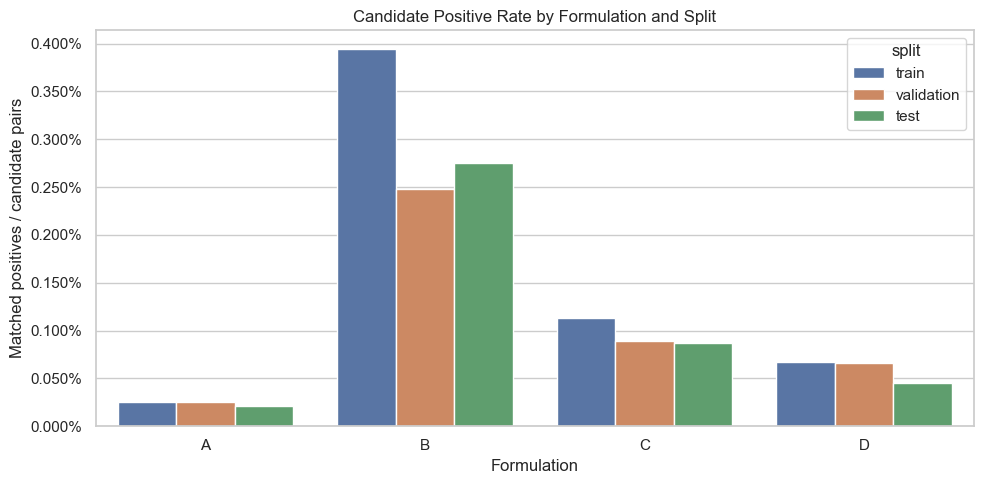

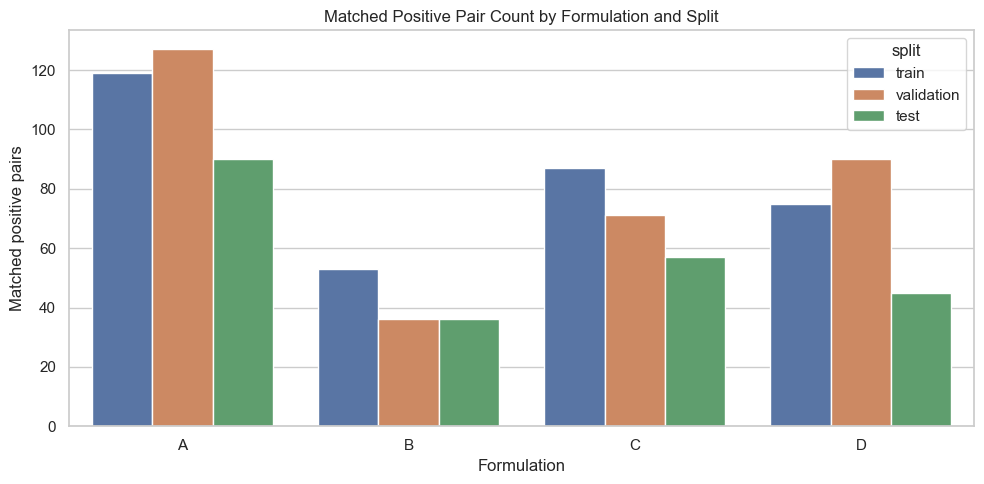

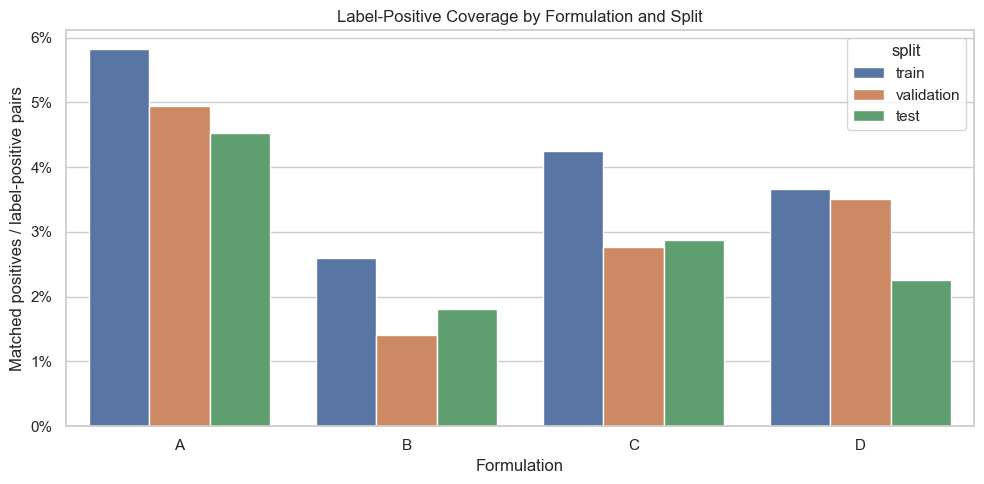

In [7]:
plot_df = comparison.copy()
plot_df["formulation_code"] = pd.Categorical(
    plot_df["formulation_code"],
    categories=["A", "B", "C", "D"],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="formulation_code",
    y="candidate_positive_rate",
    hue="split",
    ax=ax,
)
ax.set_title("Candidate Positive Rate by Formulation and Split")
ax.set_xlabel("Formulation")
ax.set_ylabel("Matched positives / candidate pairs")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3%}"))
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="formulation_code",
    y="matched_positive_pair_count",
    hue="split",
    ax=ax,
)
ax.set_title("Matched Positive Pair Count by Formulation and Split")
ax.set_xlabel("Formulation")
ax.set_ylabel("Matched positive pairs")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="formulation_code",
    y="label_positive_coverage",
    hue="split",
    ax=ax,
)
ax.set_title("Label-Positive Coverage by Formulation and Split")
ax.set_xlabel("Formulation")
ax.set_ylabel("Matched positives / label-positive pairs")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

## Decision Rubric for Selecting the Final Formulation

1. **Train matched positives**
   - Below 200 is likely too sparse for the main experiment.
   - A few hundred may be acceptable if the formulation is much more meaningful and stable.
   - 500+ is preferred.
   - Around 1000 or more would be excellent.

2. **Positive rate**
   - Must improve meaningfully over the original ~0.025% baseline.

3. **Validation/Test stability**
   - The formulation should not collapse outside the training split.
   - Validation and test should remain on a similar order of magnitude.

4. **Candidate coverage**
   - A formulation should not become so narrow that it captures an unreasonably tiny share of future purchased pairs.

5. **Business interpretation**
   - The formulation should correspond to a credible e-commerce prediction task.

## 9. Notebook Conclusion

In [8]:
summary_lookup = comparison.set_index(["formulation_code", "split"])

def metric(code: str, split: str, column: str):
    return summary_lookup.loc[(code, split), column]

conclusion = f'''
### Recommendation

The comparison does **not** produce a perfect formulation. All four options remain below the 200 train matched-positive threshold in the rubric, so the final modeling task should still be treated as sparse and experimental.

- **A, Broad Observed-Pair Baseline:** has the most train matched positives ({metric("A", "train", "matched_positive_pair_count"):,.0f}) and highest label-positive coverage ({metric("A", "train", "label_positive_coverage"):.2%}), but the positive rate remains extremely low at {metric("A", "train", "candidate_positive_rate"):.4%}.
- **B, Add-to-Cart Candidate Pairs:** has the best train positive rate ({metric("B", "train", "candidate_positive_rate"):.4%}), but only {metric("B", "train", "matched_positive_pair_count"):,.0f} train matched positives and weak label-positive coverage. It is better suited as a narrow abandoned-cart subtask than as the main V1 experiment.
- **C, High-Intent Hybrid Candidate Pairs:** offers the best balance among the four: a meaningful train positive-rate improvement ({metric("C", "train", "candidate_positive_rate"):.4%}), a credible high-intent business interpretation, and reasonably stable validation/test behavior. However, it still has only {metric("C", "train", "matched_positive_pair_count"):,.0f} train matched positives.
- **D, Recent Interaction Candidate Pairs:** is easy to explain and improves over A, but it is weaker than C on positive rate and does not solve the matched-positive scarcity.

The downstream `src/02_build_datasets.py` should therefore be implemented as a **configurable dataset builder** that supports at least A and C, with **C as the leading V1 modeling candidate** rather than an unquestioned final answer. A should remain available as the broad baseline diagnostic. If early model results are unstable, the project should revisit broader target definitions, longer observation/label windows, or a visitor-level purchase target.
'''

display(Markdown(conclusion))


### Recommendation

The comparison does **not** produce a perfect formulation. All four options remain below the 200 train matched-positive threshold in the rubric, so the final modeling task should still be treated as sparse and experimental.

- **A, Broad Observed-Pair Baseline:** has the most train matched positives (119) and highest label-positive coverage (5.82%), but the positive rate remains extremely low at 0.0249%.
- **B, Add-to-Cart Candidate Pairs:** has the best train positive rate (0.3941%), but only 53 train matched positives and weak label-positive coverage. It is better suited as a narrow abandoned-cart subtask than as the main V1 experiment.
- **C, High-Intent Hybrid Candidate Pairs:** offers the best balance among the four: a meaningful train positive-rate improvement (0.1127%), a credible high-intent business interpretation, and reasonably stable validation/test behavior. However, it still has only 87 train matched positives.
- **D, Recent Interaction Candidate Pairs:** is easy to explain and improves over A, but it is weaker than C on positive rate and does not solve the matched-positive scarcity.

The downstream `src/02_build_datasets.py` should therefore be implemented as a **configurable dataset builder** that supports at least A and C, with **C as the leading V1 modeling candidate** rather than an unquestioned final answer. A should remain available as the broad baseline diagnostic. If early model results are unstable, the project should revisit broader target definitions, longer observation/label windows, or a visitor-level purchase target.
